<a href="https://colab.research.google.com/github/mohamedessaiydy2004-afk/code/blob/main/my_own_github_going_modular.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Get data

In [ ]:
from pathlib import Path
workflow = Path('going_modular')
workflow.mkdir(parents = True, exist_ok = True)

In [ ]:
%%writefile going_modular/get_data.py
from pathlib import Path
import os, zipfile
import requests
# Create directors
def download_data(dir_name:str,
                  data_url:str,
                  ):
  data_path = Path('data/')
  image_path = data_path/dir_name
  image_path_zip = data_path/f'{dir_name}.zip'
  if image_path.is_dir():
    print(f'{image_path} already exist ,skip the download.')
  else:
    print(f'{image_path} does not exist. Create one...')
    image_path.mkdir(parents = True, exist_ok = True)

    with open(image_path_zip, 'wb') as f:
      print('Download the file...')
      request = requests.get(data_url)
      f.write(request.content)
    with zipfile.ZipFile(image_path_zip, 'r') as zip_ref:
      print('Unzip file data.')
      zip_ref.extractall(image_path)

    os.remove(image_path_zip)
  train_dir = image_path/'train'
  test_dir  = image_path/'test'
  return image_path, train_dir, test_dir

Overwriting going_modular/get_data.py


In [ ]:
from going_modular import get_data

In [ ]:
image_path, train_dir, test_dir = get_data.download_data(dir_name = 'pizza_steak_sushi',
                                                         data_url = 'https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip')
train_dir, test_dir, image_path

data/pizza_steak_sushi already exist ,skip the download.


(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'),
 PosixPath('data/pizza_steak_sushi'))

## 2. Create Datasets and DataLoaders (data_setup.py)
Once we've got data, we can then turn it into PyTorch Dataset's and DataLoader's (one for training data and one for testing data).

We convert the useful Dataset and DataLoader creation code into a function called create_dataloaders().

And we write it to file using the line %%writefile going_modular/data_setup.py.

In [ ]:
from torchvision import transforms
simple_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [ ]:
%%writefile going_modular/data_setup.py
import os
from torchvision import datasets
from torch.utils.data import DataLoader
# Set num_workers hyperparameter
NUM_WORKERS = os.cpu_count()
def create_dataloaders(train_dir,
                       test_dir,
                       transform,
                       batch_size,
                       num_workers = NUM_WORKERS):
  # Use ImageFolder to create datasets
  train_data = datasets.ImageFolder(root = train_dir, transform = transform)
  test_data  = datasets.ImageFolder(root = test_dir, transform = transform)
  # Get the class names
  class_names = train_data.classes
  # Turn the datasets into dataloaders
  train_dataloader = DataLoader(dataset = train_data,
                                batch_size = batch_size,
                                num_workers = NUM_WORKERS,
                                shuffle = True)
  test_dataloader = DataLoader(dataset = test_data,
                               batch_size = batch_size,
                               num_workers = NUM_WORKERS,
                               shuffle = False)
  return train_dataloader, test_dataloader, class_names

Overwriting going_modular/data_setup.py


In [ ]:
from going_modular import data_setup

In [ ]:
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir = train_dir,
                                                                               test_dir = test_dir,
                                                                               transform = simple_transform,
                                                                               batch_size = 32,
                                                                               )
train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7bf8b6339310>,
 ['pizza', 'steak', 'sushi'])

##3. Build the train_model.py

In [ ]:
%%writefile going_modular/train_model.py
import torch
from torch import nn
from timeit import default_timer as timer
from tqdm.auto import tqdm

def train_step(model,
               train_dataloader,
               loss_fn,
               optimizer,
               device):
  train_loss, train_acc = 0,0
  model.train()
  for batch,(X, y) in enumerate(train_dataloader):
    X, y = X.to(device), y.to(device)
    x_logits = model(X)
    x_preds = torch.argmax(x_logits, dim=1)
    loss = loss_fn(x_logits, y)
    train_loss += loss
    train_acc += (((y == x_preds).sum().item())/len(x_preds)) * 100
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  train_loss /= len(train_dataloader)
  train_acc /= len(train_dataloader)
  return train_loss, train_acc

def test_step(model,
              test_dataloader,
              loss_fn,
              device):
  test_loss, test_acc = 0,0
  model.eval()
  with torch.inference_mode():
    for batch, (X, y) in enumerate(test_dataloader):
      X, y = X.to(device), y.to(device)
      test_logits = model(X)
      test_preds = torch.argmax(test_logits, dim=1)
      test_loss += loss_fn(test_logits, y).item()
      test_acc += (((y == test_preds).sum().item()) / len(test_preds)) * 100
    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)
    return test_loss, test_acc

def train(model,
                train_dataloader,
                test_dataloader,
                optimizer,
                loss_fn,
                epochs,
                device):

  results = {'train_loss':[],
               'train_acc':[],
               'test_loss':[],
               'test_acc':[]}
  start_train = timer()
  for epoch in tqdm(range(epochs)):
    print(f'Epoch {epoch+1} -------------')
    train_loss, train_acc = train_step(model = model,
                                       train_dataloader = train_dataloader,
                                       loss_fn = loss_fn,
                                       optimizer = optimizer,
                                       device = device)
    test_loss, test_acc = test_step(model = model,
                                    test_dataloader = test_dataloader,
                                    loss_fn = loss_fn,
                                    device = device)
    print(f'train_loss : {train_loss:.4f}')
    print(f'train_acc  : {train_acc:.2f}%')
    print(f'test_loss  : {test_loss:.4f}')
    print(f'test_acc   : {test_acc:.2f}%')
    results['train_loss'].append(train_loss)
    results['test_loss'].append(test_loss)
    results['train_acc'].append(train_acc)
    results['test_acc'].append(test_acc)
  return results
  end_train = timer()
  train_time = end_train - start_train
  print(f'The model was training for {train_time // 60} min and {train_time % 60} sec.')

Overwriting going_modular/train_model.py


## 4. Model builder

In [ ]:
import torch
from torch import nn
# Set up the device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [ ]:
%%writefile going_modular/model_builder.py
import torch
from torch import nn
class TinyVGGModelV0(nn.Module):
  def __init__(self, input_shape, output_shape, hidden_units):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels = input_shape,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 0),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2, stride = 2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels  = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 0),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2, stride = 2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = hidden_units*13*13,
                  out_features = output_shape)
    )
  def forward(self, x):
    x = self.conv_block_1(x)
    #print(x.shape)
    x = self.conv_block_2(x)
    #print(x.shape)
    x = self.classifier(x)
    #print(x.shape)
    return x

Overwriting going_modular/model_builder.py


In [ ]:
import torch
image_tensor = torch.rand(size=(32,3,64,64)).to(device)
image_tensor.shape

torch.Size([32, 3, 64, 64])

In [ ]:
from going_modular import model_builder
model_0 = model_builder.TinyVGGModelV0(input_shape = 3,
                                        hidden_units = 10,
                                        output_shape = 3).to(device)
model_0

TinyVGGModelV0(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

In [ ]:
image_pred = model_0(image_tensor)
image_pred.shape

torch.Size([32, 3])

In [ ]:
# Set up the loss function and the optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_0.parameters(), lr = 0.001)

In [ ]:
from going_modular import train_model

In [ ]:
model_0_results = train_model.train(model = model_0,
                                    train_dataloader = train_dataloader,
                                    test_dataloader = test_dataloader,
                                    optimizer = optimizer,
                                    loss_fn = loss_fn,
                                    epochs = 5,
                                    device = device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1 -------------
train_loss : 1.0972
train_acc  : 41.41%
test_loss  : 1.1132
test_acc   : 26.04%
Epoch 2 -------------
train_loss : 1.0777
train_acc  : 42.58%
test_loss  : 1.1419
test_acc   : 26.04%
Epoch 3 -------------
train_loss : 1.1187
train_acc  : 30.47%
test_loss  : 1.1275
test_acc   : 26.04%
Epoch 4 -------------
train_loss : 1.0720
train_acc  : 48.05%
test_loss  : 1.0643
test_acc   : 36.27%
Epoch 5 -------------
train_loss : 1.1117
train_acc  : 35.55%
test_loss  : 1.0477
test_acc   : 35.23%


## 5. Make predictions

In [ ]:
%%writefile going_modular/util_tools.py
import torch
from torch import nn
import requests
from pathlib import Path
import torchvision
import matplotlib.pyplot as plt
from PIL import Image

# set the device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
def download_single_image(image_path:str,
                          raw_url):
  """
  image_path must ends with .jpg
  """
  data_path = Path('data/')
  image_path = data_path/image_path
  if not image_path.is_file():
    with open(image_path, 'wb') as f:
      print(f'Download {image_path}...')
      request = requests.get(raw_url)
      f.write(request.content)
      print(f'{image_path} downloaded.')
  else:
    print(f'{image_path} already exist, skip the download.')
  return image_path


# Create the model for predictions
def predict_and_plot(image_path,
                     model,
                     transform,
                     class_names,
                     device = device):
  img = Image.open(image_path)
  transformed_image = transform(img)
  model.eval()
  with torch.inference_mode():
    x_logit = model(transformed_image.unsqueeze(0).to(device))
    pred_prob = torch.softmax(x_logit ,dim=1)
    pred_label = torch.argmax(pred_prob, dim=1)
    class_name = class_names[pred_label.item()]
  print(f'Pred:{class_name}|Pred_prob:{pred_prob.max().item():.3f}%')
  plt.figure(figsize=(10,6))
  plt.imshow(img)
  plt.title(f'Pred:{class_name}|Pred_prob:{pred_prob.max().item():.3f}%')
  plt.axis(False);


# Save model
def save_model(target_dir,
               model_name,
               model):
  TARGET_DIR = Path(f'{target_dir}/')
  TARGET_DIR.mkdir(parents = True, exist_ok = True)

  assert model_name.endswith('.pth') or model_name.endswith('.pt'), 'model_name shoud end with .pth or .pt'
  MODEL_SAVE_PATH = TARGET_DIR / model_name

  print(f'Saving model to: {MODEL_SAVE_PATH}')
  torch.save(obj = model.state_dict(), f=MODEL_SAVE_PATH)
  return MODEL_SAVE_PATH
# Download model
def download_model(loaded_model,
                   model_save_path,
                   device = device):
  loaded_model.load_state_dict(torch.load(f=model_save_path))
  loaded_model = loaded_model.to(device)
  return loaded_model

Overwriting going_modular/util_tools.py


## First way for downloading image

In [ ]:
!wget https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/data/04-pizza-dad.jpeg -O pizza_image.jpg

--2026-09-11 20:46:32--  https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/data/04-pizza-dad.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2874848 (2.7M) [image/jpeg]
Saving to: ‘pizza_image.jpg’

pizza_image.jpg     100%[===================>]   2.74M  --.-KB/s    in 0.04s   

2026-09-11 20:46:32 (62.6 MB/s) - ‘pizza_image.jpg’ saved [2874848/2874848]



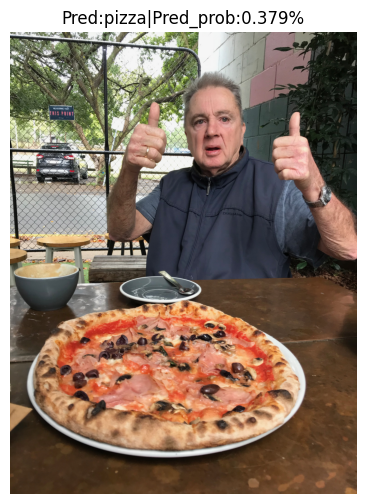

In [ ]:
util_tools.predict_and_plot(image_path = 'pizza_image.jpg',
                 model = model_0,
                 class_names = class_names,
                 transform = simple_transform)

## Second way for downloading image

In [ ]:
from going_modular import util_tools
# download single image
pizza_image = util_tools.download_single_image(image_path = 'pizza_dad.jpg',
                                               raw_url = 'https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/data/04-pizza-dad.jpeg')
pizza_image

data/pizza_dad.jpg already exist, skip the download.


PosixPath('data/pizza_dad.jpg')

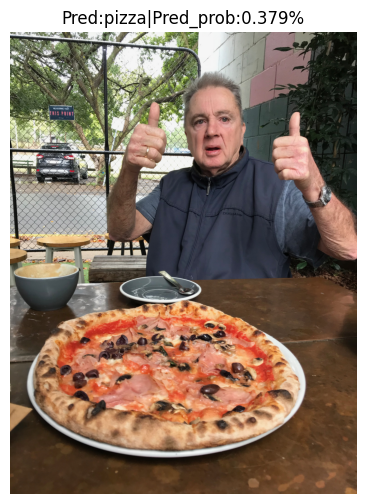

In [ ]:
util_tools.predict_and_plot(image_path = pizza_image,
                 model = model_0,
                 transform = simple_transform,
                 class_names = class_names)

In [ ]:
# Save model_0
model_save_path = util_tools.save_model(target_dir = 'models',
                                        model_name = 'model_0_TinyVGGModelV0.pth',
                                        model = model_0)
print(model_save_path)
# Download model_0
loaded_model_0 = model_builder.TinyVGGModelV0(input_shape = 3,
                                              output_shape = len(class_names),
                                              hidden_units = 10)
loaded_model_0 = util_tools.download_model(loaded_model = loaded_model_0,
                                           model_save_path = model_save_path)
loaded_model_0

Saving model to: models/model_0_TinyVGGModelV0.pth
models/model_0_TinyVGGModelV0.pth


TinyVGGModelV0(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

In [ ]:
%%writefile train.py
import os
import torch
from torch import nn
import torchvision
from torchvision import transforms
import argparse

from going_modular import data_setup, train_model, model_builder, util_tools

# Create a parser
parser = argparse.ArgumentParser(description = 'Get some hyperparameters...')
# Get an arg for num_epochs
parser.add_argument('--num_epochs',
                    default = 5,
                    type = int,
                    help = 'number for epochs used in training.')
# Get an arg for batch_size
parser.add_argument('--batch_size',
                    default = 32,
                    type = int,
                    help = 'number of sample for each batch.')
# Get an arg for hidden_units
parser.add_argument('--hidden_units',
                    default = 10,
                    type = int,
                    help = 'number of hidden units in hidden layers.')
# Get an arg for learning_rate
parser.add_argument('--learning_rate',
                    default = 0.001,
                    type = float,
                    help = 'learning rate used in training.')
# Get an arg for train_dir
parser.add_argument('--train_dir',
                    default = 'data/pizza_steak_sushi/train',
                    type = str,
                    help = 'file path for training.')
# Get an arg for test_dir
parser.add_argument('--test_dir',
                    default = 'data/pizza_steak_sushi/test',
                    type = str,
                    help = 'file path for testing.')
args = parser.parse_args()
# Set the hyperparameters
NUM_EPOCHS = args.num_epochs
BATCH_SIZE = args.batch_size
LEARNING_RATE = args.learning_rate
HIDDEN_UNITS = args.hidden_units
print(f'[INFO] the model trained for {NUM_EPOCHS} with a batch_size of size {BATCH_SIZE}, {HIDDEN_UNITS} hidden_units and a learning_rate of {LEARNING_RATE}')
# set the train_dir and test_dir
TRAIN_DIR = args.train_dir
TEST_DIR = args.test_dir
print('         [INFO]    ')
print(f'train_dir : {TRAIN_DIR}')
print(f'test_dir  : {TEST_DIR}')
# Set the device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# create the transform
simple_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])
# Get train_dataloader, test_dataloader and class_names
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir = TRAIN_DIR,
                                                                               test_dir = TEST_DIR,
                                                                               batch_size = BATCH_SIZE,
                                                                               transform = simple_transform)
model_1 = model_builder.TinyVGGModelV0(input_shape = 3,
                                       output_shape = len(class_names),
                                       hidden_units = HIDDEN_UNITS).to(device)
# Set up the loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_1.parameters(), lr = LEARNING_RATE)
# Train model
model_1_results = train_model.train(model = model_1,
                                    train_dataloader = train_dataloader,
                                    test_dataloader = test_dataloader,
                                    optimizer = optimizer,
                                    loss_fn = loss_fn,
                                    epochs = NUM_EPOCHS,
                                    device = device)

model_save_path = util_tools.save_model(target_dir = 'models',
                                        model_name = 'model_1_TinyVGGModelV0.pth',
                                        model = model_1)

Overwriting train.py


In [ ]:
!python train.py --num_epochs 5 --batch_size 32 --learning_rate 0.01 --hidden_units 128

[INFO] the model trained for 5 with a batch_size of size 32, 128 hidden_units and a learning_rate of 0.01
         [INFO]    
train_dir : data/pizza_steak_sushi/train
test_dir  : data/pizza_steak_sushi/test
  0% 0/5 [00:00<?, ?it/s]Epoch 1 -------------
train_loss : 94.7540
train_acc  : 43.75%
test_loss  : 10.8298
test_acc   : 26.04%
 20% 1/5 [00:31<02:07, 31.93s/it]Epoch 2 -------------
train_loss : 2.3354
train_acc  : 24.22%
test_loss  : 1.1122
test_acc   : 34.00%
 40% 2/5 [01:01<01:30, 30.32s/it]Epoch 3 -------------
train_loss : 1.1536
train_acc  : 28.12%
test_loss  : 1.1687
test_acc   : 22.92%
 60% 3/5 [01:31<01:00, 30.14s/it]Epoch 4 -------------
train_loss : 1.1244
train_acc  : 29.69%
test_loss  : 1.1966
test_acc   : 17.71%
 80% 4/5 [02:00<00:29, 29.90s/it]Epoch 5 -------------
train_loss : 1.1528
train_acc  : 26.17%
test_loss  : 1.1048
test_acc   : 19.79%
100% 5/5 [02:29<00:00, 30.00s/it]
Saving model to: models/model_1_TinyVGGModelV0.pth


In [ ]:
%%writefile predict.py
import torch
from torchvision import transforms
from torch import nn
import argparse
from going_modular import model_builder, util_tools

parser = argparse.ArgumentParser(description = 'Get some hyperparameters...')
# Get an arg for image_path
parser.add_argument('--image_path',
                    type = str,
                    help = 'the image path you want to predict.')
parser.add_argument('--model_path',
                    type = str,
                    default = 'models/model_0_TinyVGGModelV0.pth',
                    help = 'model path of the model used for predicting')
parser.add_argument('--hidden_units',
                    default = 10,
                    type = int,
                    help = 'number of hidden units inside hidden layers')
args = parser.parse_args()
# Set the hyperparameters
IMAGE_PATH = args.image_path
MODEL_PATH = args.model_path
HIDDEN_UNITS = args.hidden_units
# Class names
class_names = ['pizza', 'steak', 'sushi']
# Set up a transform
simple_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'''

           [INFO]
    image_path : {IMAGE_PATH}
    model_path : {MODEL_PATH}

''')
loaded_model_0 = model_builder.TinyVGGModelV0(input_shape = 3,
                                            hidden_units = HIDDEN_UNITS,
                                            output_shape = len(class_names)).to(device)
loaded_model_0 = util_tools.download_model(loaded_model = loaded_model_0,
                                           model_save_path = MODEL_PATH,
                                           device = device)
image_predicted = util_tools.predict_and_plot(image_path = IMAGE_PATH,
                                              model = loaded_model_0,
                                              transform = simple_transform,
                                              class_names = class_names)
if __name__ == '__main__':
  image_predicted

Overwriting predict.py


In [ ]:
!python predict.py --image_path data/pizza_steak_sushi/test/steak/1016217.jpg



           [INFO]
    image_path : data/pizza_steak_sushi/test/steak/1016217.jpg
    model_path : models/model_0_TinyVGGModelV0.pth
      

Pred:pizza|Pred_prob:0.376%


In [ ]:
%%writefile train.py
import torchvision
from torchvision import transforms
import torch
from torch import nn
import argparse
from going_modular import data_setup, model_builder, train_model, util_tools

# Set the device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'[INFO] the device used in this operation is : {device.upper()}')

# Set up the transform
simple_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

# Get some hyperparameters
parser = argparse.ArgumentParser(description = 'Get some hyperparametrs...')
# Get an arg for number of epochs
parser.add_argument('--num_epochs',
                    type = int,
                    default = 10,
                    help = 'number of epochs used in training.')
# Get an arg for batch size
parser.add_argument('--batch_size',
                    type = int,
                    default = 32,
                    help = 'number of sample for each batch.')
# Get an arg for number of hidden_units
parser.add_argument('--hidden_units',
                    type = int,
                    default = 10,
                    help = 'number of hidden_units inside hidden_layers.')
# Get an arg for learning rate
parser.add_argument('--learning_rate',
                    type = float,
                    default = 0.001,
                    help = 'learning rate used for optimizing the model.')
# Get an arg train_dir
parser.add_argument('--train_dir',
                    type = str,
                    default = 'data/pizza_steak_sushi/train',
                    help = 'train_dir used for training.')
# Get an arg test_dir
parser.add_argument('--test_dir',
                    type = str,
                    default = 'data/pizza_steak_sushi/test',
                    help = 'test_dir used for testing.')
args = parser.parse_args()

NUM_EPOCHS = args.num_epochs
BATCH_SIZE = args.batch_size
HIDDEN_UNITS = args.hidden_units
LEARNING_RATE = args.learning_rate
TRAIN_DIR = args.train_dir
TEST_DIR  = args.test_dir
print(f'''                              [INFO]
    The number of epochs used in training is {NUM_EPOCHS} with {BATCH_SIZE} simple in batch size,
                 a learning_rate of {LEARNING_RATE} and {HIDDEN_UNITS} hidden units
                          train_dir : {TRAIN_DIR}
                          test_dir  : {TEST_DIR}
                 ''')
# Get the train_dataloader and test_dataloader
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir = TRAIN_DIR,
                                                                               test_dir = TEST_DIR,
                                                                               transform = simple_transform,
                                                                               batch_size = BATCH_SIZE)
# Set up a model for training
model_1 = model_builder.TinyVGGModelV0(input_shape = 3,
                                    hidden_units = HIDDEN_UNITS,
                                    output_shape = len(class_names)).to(device)
# Set up a loss function and an optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_1.parameters(), lr = LEARNING_RATE)

# train the model
model_1_results = train_model.train(model = model_1,
                                    train_dataloader = train_dataloader,
                                    test_dataloader  = test_dataloader,
                                    optimizer = optimizer,
                                    loss_fn = loss_fn,
                                    epochs = NUM_EPOCHS,
                                    device = device)
model_save_path = util_tools.save_model(target_dir = 'models',
                                        model_name = 'model_1_TinyVGGModelV0.pth',
                                        model = model_1)

Overwriting train.py


In [ ]:
!python train.py --num_epochs 5 --learning_rate 0.01 --batch_size 32

[INFO] the device used in this operation is : CPU
                              [INFO] 
    The number of epochs used in training is 5 with 32 simple in batch size,
                 a learning_rate of 0.01 and 10 hidden units
                          train_dir : data/pizza_steak_sushi/train
                          test_dir  : data/pizza_steak_sushi/test
                 
  0% 0/5 [00:00<?, ?it/s]Epoch 1 -------------
train_loss : 1.0934
train_acc  : 42.58%
test_loss  : 1.1001
test_acc   : 26.04%
 20% 1/5 [00:02<00:11,  2.95s/it]Epoch 2 -------------
train_loss : 1.0898
train_acc  : 42.58%
test_loss  : 1.1057
test_acc   : 26.04%
 40% 2/5 [00:04<00:06,  2.28s/it]Epoch 3 -------------
train_loss : 1.1052
train_acc  : 30.47%
test_loss  : 1.1100
test_acc   : 26.04%
 60% 3/5 [00:06<00:04,  2.12s/it]Epoch 4 -------------
train_loss : 1.1017
train_acc  : 30.47%
test_loss  : 1.1006
test_acc   : 26.04%
 80% 4/5 [00:08<00:02,  2.04s/it]Epoch 5 -------------
train_loss : 1.0985
train_acc  : 30.